# Random Forest Analysis with just SSUSA Variables - Array Level


In [1]:
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# ------------------------------------------------------------
# Load array-level comparison table created earlier
# ------------------------------------------------------------
INPUT_FILE = "../../outputs/array_level_ssusa_iucn_comparison.pkl"

rf_array = pd.read_pickle(INPUT_FILE)

print("Shape:", rf_array.shape)
rf_array.head()

Shape: (261, 14)


,Camera_Trap_Array,ssusa_species,iucn_species,unique_nights_array,jaccard_index,n_ssusa_species,n_iucn_species,n_shared_species,n_union_species,habitat_array,development_array,feature_array,Latitude,Longitude
0,ARNWR,"{canis rufus, procyon lotor, ursus americanus,...","{myotis septentrionalis, canis rufus, procyon ...",112,0.562500,10,15,9,16,wetland,wild,road dirt,35.819010,-75.950200
1,AandM,"{pecari tajacu, procyon lotor, dasypus novemci...","{ictidomys mexicanus, spilogale putorius, cone...",63,0.473684,9,19,9,19,forest,rural,road dirt,26.211775,-97.425708
2,Abilene,"{castor canadensis, procyon lotor, dasypus nov...","{ictidomys mexicanus, mustela nigripes, spilog...",371,0.521739,14,21,12,23,grassland,rural,trail game,32.231940,-99.881940
3,AbitaFlats,"{procyon lotor, dasypus novemcinctus, canis la...","{procyon lotor, dasypus novemcinctus, canis la...",85,0.400000,6,15,6,15,forest,wild,none,30.506400,-89.976600
4,Afognak,"{tamiasciurus hudsonicus, lepus americanus, ma...","{ursus arctos, alexandromys oeconomus}",35,0.111111,8,2,1,9,forest,wild,road dirt,58.276180,-152.238110


### SSUSA-only RF model variables 

In [2]:
# Response variable:
# - jaccard_index
#
# SSUSA-only predictors:
# - unique_nights_array
# - habitat_array
# - development_array
# - feature_array

rf_df = rf_array[
    [
        "Camera_Trap_Array",
        "jaccard_index",
        "unique_nights_array",
        "habitat_array",
        "development_array",
        "feature_array"
    ]
].copy()

print("RF dataframe shape:", rf_df.shape)
rf_df.head()

RF dataframe shape: (261, 6)


,Camera_Trap_Array,jaccard_index,unique_nights_array,habitat_array,development_array,feature_array
0,ARNWR,0.562500,112,wetland,wild,road dirt
1,AandM,0.473684,63,forest,rural,road dirt
2,Abilene,0.521739,371,grassland,rural,trail game
3,AbitaFlats,0.400000,85,forest,wild,none
4,Afognak,0.111111,35,forest,wild,road dirt


In [3]:
# Data cleanup steps:
# contain missing values.

print("Missing values by column:")
print(rf_df.isna().sum())
print()

# ------------------------------------------------------------
# Fill missing categorical values, if any
# ------------------------------------------------------------
# We use "none" as a placeholder category so rows are not dropped
# unnecessarily.
rf_df["habitat_array"] = rf_df["habitat_array"].fillna("none")
rf_df["development_array"] = rf_df["development_array"].fillna("none")
rf_df["feature_array"] = rf_df["feature_array"].fillna("none")

# ------------------------------------------------------------
# Make sure numeric predictor is numeric
# ------------------------------------------------------------
rf_df["unique_nights_array"] = pd.to_numeric(
    rf_df["unique_nights_array"],
    errors="coerce"
)

# ------------------------------------------------------------
# Drop rows missing response or numeric predictor
# ------------------------------------------------------------
rf_df = rf_df.dropna(subset=["jaccard_index", "unique_nights_array"]).copy()

print("Shape after cleaning:", rf_df.shape)
rf_df.head()

Missing values by column:
Camera_Trap_Array      0
jaccard_index          0
unique_nights_array    0
habitat_array          0
development_array      0
feature_array          0
dtype: int64

Shape after cleaning: (261, 6)


,Camera_Trap_Array,jaccard_index,unique_nights_array,habitat_array,development_array,feature_array
0,ARNWR,0.562500,112,wetland,wild,road dirt
1,AandM,0.473684,63,forest,rural,road dirt
2,Abilene,0.521739,371,grassland,rural,trail game
3,AbitaFlats,0.400000,85,forest,wild,none
4,Afognak,0.111111,35,forest,wild,road dirt


In [4]:
# Verify one value per array for categorical predictors
# These columns should contain a single value per array
cols = ["habitat_array", "development_array", "feature_array"]

for col in cols:
    print(f"\nChecking column: {col}")
    
    # count how many unique values per array
    check = (
        rf_df
        .groupby("Camera_Trap_Array")[col]
        .nunique()
        .value_counts()
        .sort_index()
    )
    
    print(check)


Checking column: habitat_array
habitat_array
1    261
Name: count, dtype: int64

Checking column: development_array
development_array
1    261
Name: count, dtype: int64

Checking column: feature_array
feature_array
1    261
Name: count, dtype: int64


### One-hot encode categorical predictors

In [7]:
X_cat = pd.get_dummies(
    rf_df[["habitat_array", "development_array", "feature_array"]],
    prefix=["habitat", "development", "feature"],
    drop_first=False
)

# Convert True/False to 0/1
X_cat = X_cat.astype(int)

X_cat.head()

,habitat_anthropogenic,habitat_beach,habitat_chaparral,habitat_desert,habitat_forest,habitat_grassland,habitat_shrubland,habitat_wetland,development_rural,development_suburban,development_urban,development_wild,feature_none,feature_other,feature_road dirt,"feature_road dirt, trail hiking",feature_road paved,feature_trail game,feature_trail hiking,feature_water source
0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0
1,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
2,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0


### Combine numeric and categorical predictors

In [8]:
# Numeric predictor
X_num = rf_df[["unique_nights_array"]].copy()

# Combine numeric + one-hot encoded categorical predictors
X = pd.concat([X_num, X_cat], axis=1)

# Response variable
y = rf_df["jaccard_index"].copy()

print("Predictor matrix shape:", X.shape)
print("Response shape:", y.shape)

X.head()

Predictor matrix shape: (261, 21)
Response shape: (261,)


,unique_nights_array,habitat_anthropogenic,habitat_beach,habitat_chaparral,habitat_desert,habitat_forest,habitat_grassland,habitat_shrubland,habitat_wetland,development_rural,...,development_urban,development_wild,feature_none,feature_other,feature_road dirt,"feature_road dirt, trail hiking",feature_road paved,feature_trail game,feature_trail hiking,feature_water source
0,112,0,0,0,0,0,0,0,1,0,...,0,1,0,0,1,0,0,0,0,0
1,63,0,0,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,371,0,0,0,0,0,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0
3,85,0,0,0,0,1,0,0,0,0,...,0,1,1,0,0,0,0,0,0,0
4,35,0,0,0,0,1,0,0,0,0,...,0,1,0,0,1,0,0,0,0,0


### Random Forest Train / Test 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,       # 20% test set
    random_state=42      # reproducible split
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (208, 21)
X_test shape: (53, 21)
y_train shape: (208,)
y_test shape: (53,)


In [10]:
# Fit the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,    # number of trees
    random_state=42,     # reproducibility
    n_jobs=-1            # use all available CPU cores
)

# Train model on training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [12]:
# # Use trained model to predict on unseen test data
y_pred = rf_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Array-level RF performance (SSUSA-only variables)")
print(f"R²   : {r2:.3f}")
print(f"RMSE : {rmse:.3f}")

Array-level RF performance (SSUSA-only variables)
R²   : -0.142
RMSE : 0.172


### Visualizations 

In [14]:
importances = rf_model.feature_importances_

# Create dataframe for easier viewing
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": importances
})

# Sort descending
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance.head(15)

,feature,importance
0,unique_nights_array,0.516351
5,habitat_forest,0.068067
12,development_wild,0.067638
14,feature_other,0.047330
15,feature_road dirt,0.045050
9,development_rural,0.033320
18,feature_trail game,0.028704
19,feature_trail hiking,0.028211
10,development_suburban,0.025948
8,habitat_wetland,0.025841


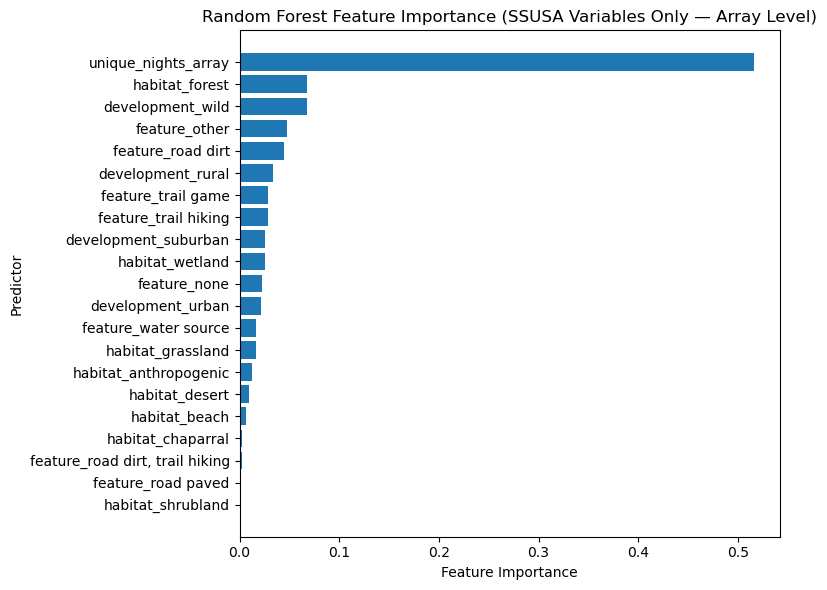

In [15]:
# Sort again just to be safe
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(8,6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")
plt.title("Random Forest Feature Importance (SSUSA Variables Only — Array Level)")

plt.tight_layout()
plt.show()